In [2]:
import ee
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import colors
from matplotlib.ticker import MaxNLocator

In [3]:
ee.Authenticate()
ee.Initialize(project='ee-jaquelinevigolo')

In [4]:
# Define the region of interest
asset_path = 'users/jaquelinevigolo/lm_bioma_250'
biomes = ee.FeatureCollection(asset_path)  # Load the asset as a FeatureCollection

# # Filter the feature collection by 'id' field for different regions
amazon = biomes.filter(ee.Filter.eq('CD_Bioma', 1))
caatinga = biomes.filter(ee.Filter.eq('CD_Bioma', 2))
cerrado = biomes.filter(ee.Filter.eq('CD_Bioma', 3))
atlanticForest = biomes.filter(ee.Filter.eq('CD_Bioma', 4))
pampa = biomes.filter(ee.Filter.eq('CD_Bioma', 5))
pantanal = biomes.filter(ee.Filter.eq('CD_Bioma', 6))


# asset_path = 'FAO/GAUL/2015/level0'
# brazil = ee.FeatureCollection(asset_path)  # Load the asset as a FeatureCollection

In [4]:
# # Export as a GeoJSON to Google Drive
# task = ee.batch.Export.table.toDrive(
#     collection=biomes,
#     description='export_fc',
#     folder='GEE',
#     fileNamePrefix='biomes',
#     fileFormat='GeoJSON'  # or 'SHP'
# )

# task.start()

In [5]:
# Load exported FeatureCollection (GeoJSON or SHP)
biome_gdf = gpd.read_file("biomes.geojson")

In [6]:
biome_gdf['biome'] = ['Pantanal', 'Amazon', 'Caatinga', 'Pampa', 'Cerrado', 'Atlantic Forest']

In [7]:
biome_gdf

,id,Bioma,CD_Bioma,geometry,biome
0,00000000000000000004,Pantanal,6,"POLYGON ((-59.14083 -16.23596, -59.14067 -16.2...",Pantanal
1,00000000000000000005,Amazônia,1,"MULTIPOLYGON (((-58.94884 -16.30122, -58.95258...",Amazon
2,00000000000000000002,Caatinga,2,"POLYGON ((-45.07814 -16.03011, -45.07806 -16.0...",Caatinga
3,00000000000000000003,Pampa,5,"POLYGON ((-57.64958 -30.18863, -57.64954 -30.1...",Pampa
4,00000000000000000000,Cerrado,3,"POLYGON ((-60.47259 -12.48017, -60.47256 -12.4...",Cerrado
5,00000000000000000001,Mata Atlântica,4,"MULTIPOLYGON (((-41.95994 -22.88334, -41.95919...",Atlantic Forest


In [8]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import rasterio
# import rasterio.mask
# from rasterio.plot import show
# import geopandas as gpd
# from matplotlib import colors

# # -------------------------------------------------
# # SETTINGS
# # -------------------------------------------------
# tif_directory = r"D:\VSCode\MapBiomas-Award\trend_percent"

# rainfall_indices = ["Rx5day", "R99pTOT", "R20"]

# # biome_gdf must contain one polygon per biome
# biome_names = ['Amazon', 'Caatinga', 'Cerrado', 'Atlantic Forest', 'Pampa', 'Pantanal']

# n_rows = len(biome_names)
# n_cols = len(rainfall_indices)

# fig, axes = plt.subplots(
#     n_rows,
#     n_cols,
#     figsize=(8.27, 11.69),  # A4 portrait
# )

# # Ensure 2D axes
# if n_rows == 1:
#     axes = np.expand_dims(axes, axis=0)
# if n_cols == 1:
#     axes = np.expand_dims(axes, axis=1)

# # -------------------------------------------------
# # LOOP THROUGH INDICES
# # -------------------------------------------------
# for j, index_name in enumerate(rainfall_indices):

#     # Load raster once per index
#     filename = f"trendPercent_CHIRPS_{index_name}_1987-2023.tif"
#     filepath = os.path.join(tif_directory, filename)

#     if not os.path.exists(filepath):
#         print(f"Missing: {filepath}")
#         continue

#     with rasterio.open(filepath) as src:

#         # Reproject biome if needed
#         if biome_gdf.crs != src.crs:
#             biome_proj = biome_gdf.to_crs(src.crs)
#         else:
#             biome_proj = biome_gdf.copy()

#         # --- Determine global color range for this index ---
#         data = src.read(1)
#         abs_max = np.nanmax(np.abs(data))
#         norm = colors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

#         cmap = plt.cm.RdBu_r
#         cmap.set_bad("w")

#         # ---------------------------------------------
#         # LOOP THROUGH BIOMES
#         # ---------------------------------------------
#         for i, biome in enumerate(biome_names):

#             ax = axes[i, j]

#             biome_geom = biome_proj[
#                 biome_proj["biome"] == biome
#             ]

#             geoms = [feature["geometry"]
#                      for feature in biome_geom.__geo_interface__["features"]]

#             # Clip raster to biome
#             out_image, out_transform = rasterio.mask.mask(
#                 src,
#                 geoms,
#                 crop=True,
#                 nodata=np.nan
#             )

#             # Plot raster
#             image = show(
#                 out_image,
#                 transform=out_transform,
#                 ax=ax,
#                 cmap=cmap,
#                 norm=norm
#             )

#             # Plot biome boundary
#             biome_geom.boundary.plot(
#                 ax=ax,
#                 edgecolor="black",
#                 linewidth=0.6
#             )

#             if i == 0:
#                 ax.set_title(index_name, fontsize=10, weight="bold")

#             if j == 0:
#                 ax.text(
#                     -0.1, 0.5, biome,
#                     transform=ax.transAxes,
#                     rotation=90,
#                     va='center',
#                     ha='center',
#                     fontsize=10,
#                     weight='bold'
#                 )

#             ax.axis("off")

#         # ---------------------------------------------
#         # Shared Colorbar per column (index)
#         # ---------------------------------------------
#         cax = fig.add_axes([
#             0.15 + j*0.28,   # horizontal position
#             0.09,            # vertical position
#             0.2,             # width
#             0.015            # height
#         ])

#         cbar = fig.colorbar(
#             image.get_children()[0],
#             cax=cax,
#             orientation='horizontal'
#         )

#         cbar.set_label('% per year')

# # -------------------------------------------------
# # FINAL LAYOUT
# # -------------------------------------------------
# # plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
# plt.savefig(r'D:\VSCode\MapBiomas-Award\Figs\rainfall_indices_Maps.png', dpi=300)
# plt.show()

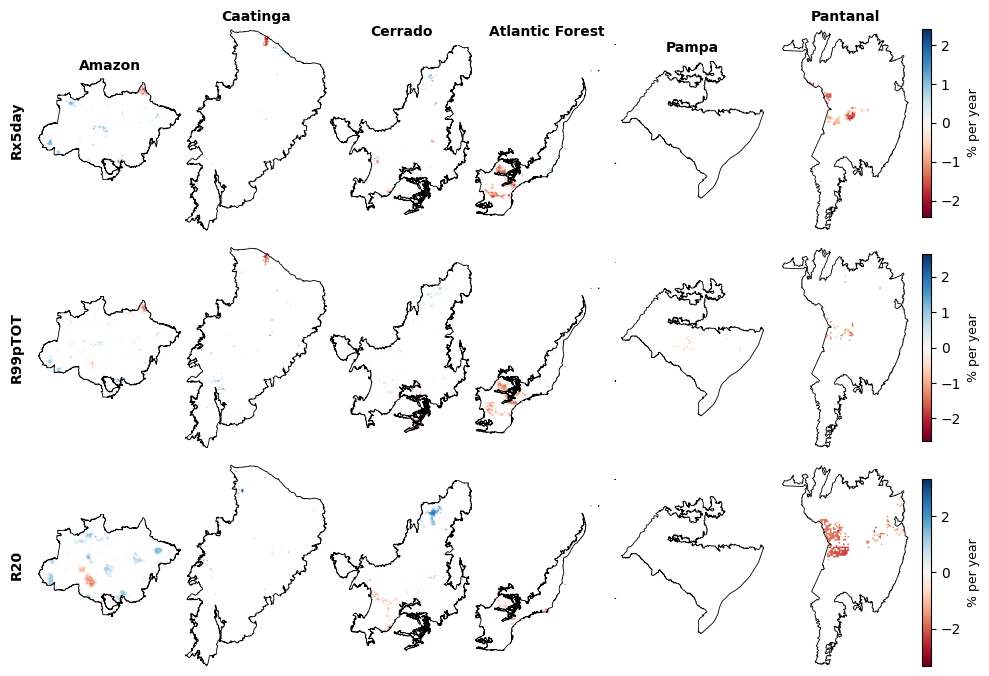

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import rasterio.mask
from rasterio.plot import show
import geopandas as gpd
from matplotlib import colors

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
tif_directory = r"D:\VSCode\MapBiomas-Award\trend_percent"

rainfall_indices = ["Rx5day", "R99pTOT", "R20"]
# rainfall_indices = ["R99pTOT"]
biome_names = ['Amazon', 'Caatinga', 'Cerrado',
               'Atlantic Forest', 'Pampa', 'Pantanal']
# biome_names = ['Pampa']

# 🔁 SWITCHED
n_rows = len(rainfall_indices)
n_cols = len(biome_names)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(11.69, 8.27),  # A4 landscape now makes more sense
)

# Ensure 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# -------------------------------------------------
# LOOP THROUGH INDICES (ROWS NOW)
# -------------------------------------------------
for i, index_name in enumerate(rainfall_indices):

    filename = f"trendPercent_CHIRPS_{index_name}_1987-2023.tif"
    filepath = os.path.join(tif_directory, filename)

    if not os.path.exists(filepath):
        print(f"Missing: {filepath}")
        continue

    with rasterio.open(filepath) as src:

        if biome_gdf.crs != src.crs:
            biome_proj = biome_gdf.to_crs(src.crs)
        else:
            biome_proj = biome_gdf.copy()

        data = src.read(1)
        abs_max = np.nanmax(np.abs(data))
        norm = colors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

        cmap = plt.cm.RdBu
        cmap.set_bad("white")

        # ---------------------------------------------
        # LOOP THROUGH BIOMES (COLUMNS NOW)
        # ---------------------------------------------
        for j, biome in enumerate(biome_names):

            ax = axes[i, j]

            biome_geom = biome_proj[
                biome_proj["biome"] == biome
            ]

            geoms = [f["geometry"]
                     for f in biome_geom.__geo_interface__["features"]]

            out_image, out_transform = rasterio.mask.mask(
                src,
                geoms,
                crop=True,
                nodata=np.nan
            )

            image = show(
                out_image,
                transform=out_transform,
                ax=ax,
                cmap=cmap,
                norm=norm
            )

            biome_geom.boundary.plot(
                ax=ax,
                edgecolor="black",
                linewidth=0.6
            )

            # ---- Column titles (top row only)
            if i == 0:
                ax.set_title(biome, fontsize=10, weight="bold")

            # ---- Row labels (left column only)
            if j == 0:
                ax.text(
                    -0.15, 0.5, index_name,
                    transform=ax.transAxes,
                    rotation=90,
                    va='center',
                    ha='center',
                    fontsize=10,
                    weight='bold'
                )

            ax.axis("off")

        # ---------------------------------------------
        # Shared Vertical Colorbar per ROW (per index)
        # ---------------------------------------------
        cbar = fig.colorbar(
            image.get_children()[0],
            ax=axes[i, :],        # entire row
            orientation='vertical',
            fraction=0.025,       # thickness
            pad=0.02              # spacing from plots
        )

        cbar.set_label('% per year', fontsize=9)

# -------------------------------------------------
# FINAL LAYOUT
# -------------------------------------------------
plt.subplots_adjust(wspace=0.02, hspace=0.08, right=0.87)
plt.savefig(r'D:\VSCode\MapBiomas-Award\Figs\rainfall_indices_Maps.png', dpi=300, bbox_inches='tight')
plt.show()

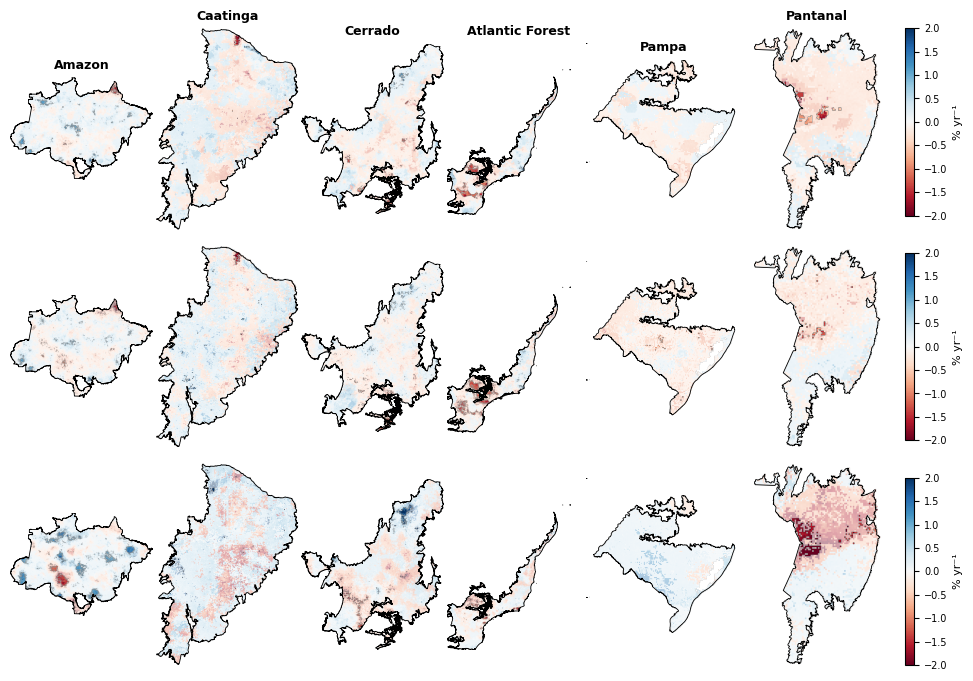

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import rasterio.mask
import geopandas as gpd
from rasterio.plot import plotting_extent
from matplotlib import colors

# -------------------------------------------------
# CONFIGURATIONS
# -------------------------------------------------
tif_dir = r"D:\VSCode\MapBiomas-Award\trend_percent"

rainfall_indices = ["Rx5day", "R99pTOT", "R20"]
biome_names = ['Amazon', 'Caatinga', 'Cerrado', 'Atlantic Forest', 'Pampa', 'Pantanal']

# Mantemos a mesma escala para todos os biomas para permitir comparação
norm = colors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
cmap = plt.cm.RdBu

fig, axes = plt.subplots(len(rainfall_indices), len(biome_names), figsize=(11.69, 8.27))

for i, index_name in enumerate(rainfall_indices):
    path_no_sign = os.path.join(tif_dir, f"trendPercent_noSign_CHIRPS_{index_name}_1987-2023.tif")
    path_sign = os.path.join(tif_dir, f"trendPercent_CHIRPS_{index_name}_1987-2023.tif")

    with rasterio.open(path_no_sign) as src_base, rasterio.open(path_sign) as src_sig:
        # Reprojetar Bioma apenas uma vez por linha
        biome_proj = biome_gdf.to_crs(src_base.crs)

        for j, biome in enumerate(biome_names):
            ax = axes[i, j]
            biome_geom = biome_proj[biome_proj["biome"] == biome]
            geoms = [f["geometry"] for f in biome_geom.__geo_interface__["features"]]
            
            # 1. MASK DOS DOIS RASTERS
            out_no_sign, out_trans = rasterio.mask.mask(src_base, geoms, crop=True, nodata=np.nan)
            out_sign, _ = rasterio.mask.mask(src_sig, geoms, crop=True, nodata=np.nan)
            
            ext = plotting_extent(out_no_sign[0], out_trans)

            # 2. PLOT: TENDÊNCIA NÃO SIGNIFICATIVA (Transparente/Faded)
            # Alpha 0.2 deixa as cores bem suaves, apenas como contexto
            ax.imshow(out_no_sign[0], cmap=cmap, norm=norm, extent=ext, origin='upper', alpha=0.4, zorder=1)

            # 3. PLOT: TENDÊNCIA SIGNIFICATIVA (Sólida/Forte)
            # Alpha 1.0 garante que o que é estatisticamente relevante "salte" aos olhos
            img = ax.imshow(out_sign[0], cmap=cmap, norm=norm, extent=ext, origin='upper', alpha=1.0, zorder=2)

            # 4. BIOME BOUNDARY
            biome_geom.boundary.plot(ax=ax, edgecolor="black", linewidth=0.6, zorder=3)
            
            # Títulos e labels
            if i == 0: ax.set_title(biome, fontsize=9, fontweight="bold")
            if j == 0: 
                ax.set_ylabel(index_name, fontsize=9, fontweight="bold", labelpad=10)
            
            ax.axis("off")

        # Colorbar única por linha para economizar espaço no A4
        cbar = fig.colorbar(img, ax=axes[i, :], orientation='vertical', fraction=0.012, pad=0.02)
        cbar.ax.tick_params(labelsize=7)
        cbar.set_label('% yr⁻¹', fontsize=8)

plt.subplots_adjust(wspace=0.02, hspace=0.08, right=0.87)
plt.savefig(r'D:\VSCode\MapBiomas-Award\Figs\Trend_Highlight_Significance.png', dpi=600, bbox_inches='tight')
plt.show()

In [14]:
csv_path

'D:\\VSCode\\MapBiomas-Award\\trend_percent\\csvFiles_byBiome\\Rx5day_percentTrend_CHIRPS_5.csv'